In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Consistent plot styling
sns.set_theme(style="whitegrid")

# Load data
products = pd.read_csv("../data/products.csv")
df = pd.read_csv("../data/features.csv", parse_dates=["sale_date"])
print(df.shape)
df.head()

(1350, 14)


,sale_id,product_id,quantity_sold,sale_date,name,category,shelf_life_days,current_stock,rolling_avg_7d,rolling_avg_14d,rolling_std_7d,weekly_total,day_of_week,days_until_stockout
0,1,1,54,2024-01-01,Bananas,Perishable,5,346,54.0,54.0,0.00,54,0,6.4
1,2,1,33,2024-01-02,Bananas,Perishable,5,313,43.5,43.5,14.85,87,1,7.2
2,3,1,48,2024-01-03,Bananas,Perishable,5,265,45.0,45.0,10.82,135,2,5.9
3,4,1,51,2024-01-04,Bananas,Perishable,5,214,46.5,46.5,9.33,186,3,4.6
4,5,1,44,2024-01-05,Bananas,Perishable,5,400,46.0,46.0,8.15,230,4,8.7


In [4]:
# isolating the latest snapshot
latest = (
    df.sort_values("sale_date")
    .groupby("product_id")
    .last()
    .reset_index()
)

print(f"Latest snapshot date: {latest['sale_date'].max().date()}")
print(f"Products: {len(latest)}")
latest[["name", "sale_date", "current_stock", "rolling_avg_7d", "days_until_stockout"]]

Latest snapshot date: 2024-03-30
Products: 15


,name,sale_date,current_stock,rolling_avg_7d,days_until_stockout
0,Bananas,2024-03-30,216,35.14,6.1
1,Apples,2024-03-30,235,30.71,7.7
2,Tomatoes,2024-03-30,200,22.86,8.7
3,Lettuce,2024-03-30,59,19.57,3.0
4,Carrots,2024-03-30,367,20.43,18.0
5,Whole Milk,2024-03-30,443,58.43,7.6
6,Yogurt,2024-03-30,367,27.57,13.3
7,Butter,2024-03-30,209,9.57,21.8
8,Orange Juice,2024-03-30,980,36.86,26.6
9,Cheddar Cheese,2024-03-30,323,14.29,22.6


#### Historical rows were needed to compute rolling features, but the forecast decision is made from the most recent numbers only.

In [6]:
# Baseline forecast
# Predicted demand for the next 7 days = rolling_avg_7d × 7
latest["predicted_weekly_demand"] = (latest["rolling_avg_7d"] * 7).round(1)
latest["projected_stock"] = (latest["current_stock"] - latest["predicted_weekly_demand"]).round(1)
latest["at_risk"] = latest["projected_stock"] <= 0
latest[["name", "category", "current_stock",
        "predicted_weekly_demand", "projected_stock", "at_risk"]]

,name,category,current_stock,predicted_weekly_demand,projected_stock,at_risk
0,Bananas,Perishable,216,246.0,-30.0,True
1,Apples,Perishable,235,215.0,20.0,False
2,Tomatoes,Perishable,200,160.0,40.0,False
3,Lettuce,Perishable,59,137.0,-78.0,True
4,Carrots,Perishable,367,143.0,224.0,False
5,Whole Milk,Refrigerated,443,409.0,34.0,False
6,Yogurt,Refrigerated,367,193.0,174.0,False
7,Butter,Refrigerated,209,67.0,142.0,False
8,Orange Juice,Refrigerated,980,258.0,722.0,False
9,Cheddar Cheese,Refrigerated,323,100.0,223.0,False


#### This calculates the prediceted demand for the next 7 days, assuming each week looks like the one before.

In [7]:
# Risk report test
risk_products = latest[latest["at_risk"]].sort_values("projected_stock")

print(f" {len(risk_products)} product(s) at risk of stockout this week:\n")
print(risk_products[[
    "name", "category", "current_stock",
    "predicted_weekly_demand", "projected_stock"
]].to_string(index=False))

 2 product(s) at risk of stockout this week:

   name   category  current_stock  predicted_weekly_demand  projected_stock
Lettuce Perishable             59                    137.0            -78.0
Bananas Perishable            216                    246.0            -30.0


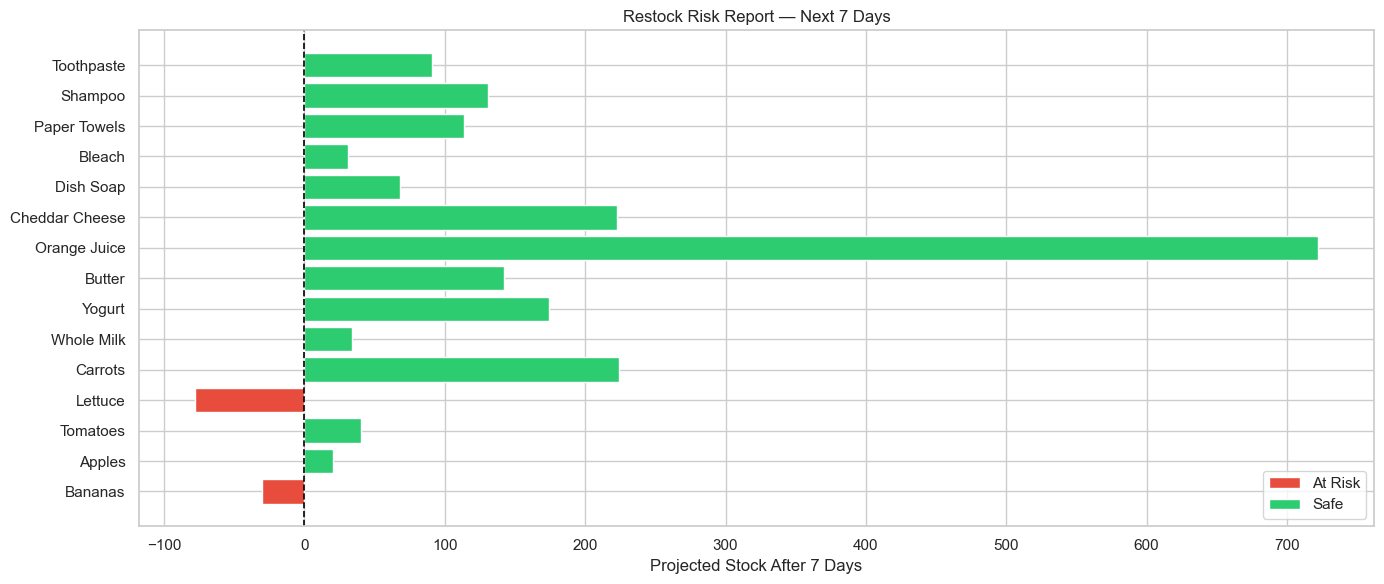

In [8]:
# visualizing risk
fig, ax = plt.subplots(figsize=(14, 6))

colors = ["#e74c3c" if r else "#2ecc71" for r in latest["at_risk"]]

bars = ax.barh(latest["name"], latest["projected_stock"], color=colors)

ax.axvline(x=0, color="black", linewidth=1.2, linestyle="--")
ax.set_xlabel("Projected Stock After 7 Days")
ax.set_title("Restock Risk Report — Next 7 Days")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#e74c3c", label="At Risk"),
                   Patch(facecolor="#2ecc71", label="Safe")]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

In [9]:
# Forecast accuracy check
BACKTEST_CUTOFF = 83

backtest_df = (
    df[df["sale_date"] <= df["sale_date"].unique()[BACKTEST_CUTOFF - 1]]
    .groupby("product_id")
    .last()
    .reset_index()
)

backtest_df["predicted_weekly_demand"] = (backtest_df["rolling_avg_7d"] * 7).round(1)
actual_last_7 = (
    df[df["sale_date"] > df["sale_date"].unique()[BACKTEST_CUTOFF - 1]]
    .groupby("product_id")["quantity_sold"]
    .sum()
    .reset_index()
    .rename(columns={"quantity_sold": "actual_weekly_demand"})
)
backtest_df = backtest_df.merge(actual_last_7, on="product_id")

backtest_df["error"] = backtest_df["predicted_weekly_demand"] - backtest_df["actual_weekly_demand"]
backtest_df["abs_error"] = backtest_df["error"].abs()
backtest_df["pct_error"] = (backtest_df["abs_error"] / backtest_df["actual_weekly_demand"] * 100).round(1)

mae  = backtest_df["abs_error"].mean().round(2)
mape = backtest_df["pct_error"].mean().round(2)

print(f"MAE:  {mae} units")
print(f"MAPE: {mape}%\n")

print(backtest_df[[
    "name", "predicted_weekly_demand",
    "actual_weekly_demand", "abs_error", "pct_error"
]].sort_values("pct_error", ascending=False).to_string(index=False))

MAE:  23.07 units
MAPE: 12.42%

          name  predicted_weekly_demand  actual_weekly_demand  abs_error  pct_error
       Bananas                    321.0                   246       75.0       30.5
       Lettuce                    102.0                   137       35.0       25.5
    Whole Milk                    311.0                   409       98.0       24.0
      Tomatoes                    125.0                   160       35.0       21.9
    Toothpaste                     75.0                    67        8.0       11.9
  Paper Towels                    120.0                   108       12.0       11.1
        Butter                     60.0                    67        7.0       10.4
Cheddar Cheese                     90.0                   100       10.0       10.0
       Carrots                    157.0                   143       14.0        9.8
        Apples                    234.0                   215       19.0        8.8
     Dish Soap                     54.0     

#### Since no machine learning is used yet, the baseline is good. The table is showing the products in order of highest rolling average errors. Products like bananas and lettuce being at the top is a good sign, since these products are one with a short shelf life and they are more frequently restocked than others.

### Note: Since the data used here is synthetic(for now), it's not possible to validate against future data. So instead back-test is used. Days 1-83 are used to predict days 84-90, and then compare against the actual sales. This should give a good general idea of the performance(again for now until more realistic data is aquired).

In [10]:
output_cols = [
    "product_id", "name", "category",
    "current_stock", "rolling_avg_7d",
    "predicted_weekly_demand", "projected_stock", "at_risk"
]

latest[output_cols].to_csv("../data/forecast.csv", index=False)
print("Forecast saved → ../data/forecast.csv")

Forecast saved → ../data/forecast.csv
